<a href="https://colab.research.google.com/github/jivaniaadit/factor_xa_cheminformatics/blob/main/notebooks/week1_day3_substructure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit -q
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors

In [ ]:

mol.HasSubstructMatch(pattern_mol)   # returns True or False
mol.GetSubstructMatches(pattern_mol) # returns tuple of atom index tuples
#Where pattern_mol = Chem.MolFromSmarts('your_smarts_string')

NameError: name 'pattern_mol' is not defined

In [ ]:
aspirin = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')
carboxylic_acid = Chem.MolFromSmarts('C(=O)[OH]')
ester = Chem.MolFromSmarts('C(=O)O[#6]')

print(aspirin.HasSubstructMatch(carboxylic_acid))
print(aspirin.GetSubstructMatches(carboxylic_acid))
print(aspirin.GetSubstructMatches(ester))

True
((10, 11, 12),)
((1, 2, 3, 4),)


In [ ]:
drugs = {
    'Aspirin': 'CC(=O)Oc1ccccc1C(=O)O',
    'Ibuprofen': 'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
    'Acetaminophen': 'CC(=O)Nc1ccc(O)cc1',
    'Caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'Penicillin G': 'CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O',
    'Diazepam': 'CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21',
    'Propranolol': 'CC(C)NCC(O)COc1cccc2ccccc12',
    'Fluoxetine': 'CNCCC(Oc1ccc(C(F)(F)F)cc1)c1ccccc1',
    'Atorvastatin': 'CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CC[C@@H](O)C[C@@H](O)CC(=O)O',
    'Metformin': 'CN(C)C(=N)NC(=N)N',
}

patterns = {
    'Carboxylic acid': 'C(=O)[OH]',
    'Amide': 'C(=O)N',
    'Aromatic ring': 'c1ccccc1',
    'Primary amine': '[NX3;H2]',
    'Secondary amine': '[NX3;H1;!$(NC=O)]',
    'Tertiary amine': '[NX3;H0;!$(NC=O)]',
    'Hydroxyl': '[OX2H]',
    'Ether': '[OD2]([#6])[#6]',
    'Halogen': '[F,Cl,Br,I]',
    'Beta lactam': 'C1(=O)NCC1',
    'Sulfonamide': 'S(=O)(=O)N',
}
list_of_patterns = {}
for name, smarts in patterns.items():
  query_mol = Chem.MolFromSmarts(smarts)
  list_of_patterns[name] = query_mol

def pharmacophore(mol):
  return {name: mol.HasSubstructMatch(query_mol) for name, query_mol in list_of_patterns.items()}

results = []
for name, smiles in drugs.items():
  mol = Chem.MolFromSmiles(smiles)
  if mol is None:
    continue
  pharmacophore_matches = pharmacophore(mol)
  pharmacophore_matches['Name'] = name
  results.append(pharmacophore_matches)

df = pd.DataFrame(results)
#feedback:
df = df[['Name'] + [c for c in df.columns if c != 'Name']]     #Name comes first for readability
df


,Name,Carboxylic acid,Amide,Aromatic ring,Primary amine,Secondary amine,Tertiary amine,Hydroxyl,Ether,Halogen,Beta lactam,Sulfonamide
0,Aspirin,True,False,True,False,False,False,True,True,False,False,False
1,Ibuprofen,True,False,True,False,False,False,True,False,False,False,False
2,Acetaminophen,False,True,True,False,False,False,True,False,False,False,False
3,Caffeine,False,False,False,False,False,False,False,False,False,False,False
4,Penicillin G,True,True,True,False,False,False,True,False,False,True,False
5,Diazepam,False,True,True,False,False,False,False,False,True,False,False
6,Propranolol,False,False,True,False,True,False,True,True,False,False,False
7,Fluoxetine,False,False,True,False,True,False,False,True,True,False,False
8,Atorvastatin,True,True,True,False,False,False,True,False,True,False,False
9,Metformin,False,False,False,True,True,True,False,False,False,False,False


In [ ]:
#Reverse the search.
mol = Chem.MolFromSmiles(drugs['Penicillin G'])
for name, smarts in patterns.items():
    pattern = Chem.MolFromSmarts(smarts)
    if mol.HasSubstructMatch(pattern):
        print(name)

Carboxylic acid
Amide
Aromatic ring
Hydroxyl
Beta lactam


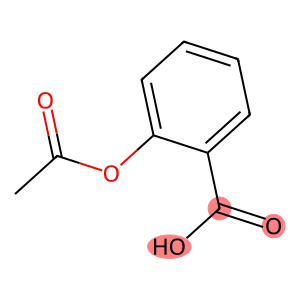

In [ ]:
mol = Chem.MolFromSmiles(drugs['Aspirin'])
pattern = Chem.MolFromSmarts('C(=O)[OH]')
match = mol.GetSubstructMatch(pattern)
Draw.MolToImage(mol, highlightAtoms=match)

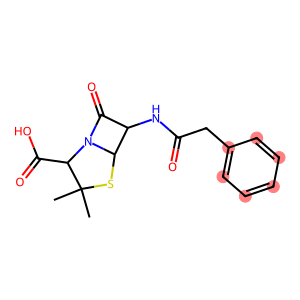

In [ ]:
mol = Chem.MolFromSmiles(drugs['Penicillin G'])
pattern = Chem.MolFromSmarts('c1ccccc1')
match = mol.GetSubstructMatch(pattern)
Draw.MolToImage(mol, highlightAtoms = match)